# Language Classifier Dataset Pipeline
**Project:** SRH AI Platform — ALU Capstone (Kinyarwanda–English bilingual)
**Model:** Model 2 — Language Identification (Kinyarwanda vs English)
**Purpose:** Build one labeled EN/RW text dataset by combining open sources, the same
way the topic pipeline combined MedMCQA / AdaptLLM / HealthCareMagic / AfriMedQA.

## Classes
| ID | Language | Source(s) |
|---|---|---|
| 0 | `english` | Project SRH text — topic dataset + safety dataset (already domain-relevant) |
| 1 | `kinyarwanda` | KINNEWS (Kinyarwanda news, **MIT**) + SIB-200 `kin_Latn` (**CC-BY-SA-4.0**) |

**Code-switched / mixed text:** no open, labeled Kinyarwanda–English code-switch corpus
was found on the Hugging Face Hub, so this is a **binary** EN vs RW dataset and
code-switching detection is flagged as **future work** (see final summary).

## Output
`data/Language_Classifier_data/lang_{train,val,test}.csv` + `lang_labels_full.csv` +
`lang_label_map.json`, columns: `text`, `language`, `label` (int 0/1), `source`.

---
## STEP 0 — Install & import

In [1]:
!pip install -q datasets pandas scikit-learn matplotlib seaborn
print('deps ready')

deps ready



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

LANG_MAP   = {'english': 0, 'kinyarwanda': 1}
LANG_NAMES = {v: k for k, v in LANG_MAP.items()}

# Anchor all paths to the repo root (walk up for a marker) so the notebook works
# no matter which directory it is launched from (root, notebooks/, data/X/, Colab).
def find_repo_root(start='.'):
    p = os.path.abspath(start)
    while True:
        if (os.path.isdir(os.path.join(p, 'data', 'Topic_Classifier_data'))
                or os.path.isdir(os.path.join(p, '.git'))):
            return p
        parent = os.path.dirname(p)
        if parent == p:
            return os.path.abspath(start)
        p = parent

REPO_ROOT = find_repo_root()
DATA_ROOT = os.path.join(REPO_ROOT, 'data')
OUT_DIR   = os.path.join(DATA_ROOT, 'Language_Classifier_data')
os.makedirs(OUT_DIR, exist_ok=True)

MIN_LEN, MAX_LEN = 15, 300   # focus on query-length text; avoids long-article length confound

def clean_text(t):
    if not isinstance(t, str):
        return ''
    t = t.replace('\ufffd', "'")                       # mangled apostrophe -> '
    t = re.sub(r'\s+', ' ', t).strip()
    t = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', t)
    return t

def prep(series, language, source):
    s = pd.Series(series).dropna().astype(str).map(clean_text)
    df = pd.DataFrame({'text': s})
    df = df[(df['text'].str.len() >= MIN_LEN) & (df['text'].str.len() <= MAX_LEN)]
    df['language'] = language
    df['source']   = source
    return df.drop_duplicates(subset='text').reset_index(drop=True)

print('Setup complete. DATA_ROOT =', DATA_ROOT)

C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. DATA_ROOT = C:\Users\USER\srh-ml-model\data


---
## STEP 1 — English from the project's own SRH text
Reuses the already-cleaned English text from the **topic** classifier dataset and the
**safety** classifier dataset (two domains: medical Q&A + general/conversational), which
also reduces an English=medical vs Kinyarwanda=news domain confound.

In [3]:
en_parts = []

topic = pd.read_csv(os.path.join(DATA_ROOT, 'Topic_Classifier_data', 'topic_labels_full.csv'))
en_parts.append(prep(topic['text'], 'english', 'topic_dataset'))
print(f'  topic_dataset English: {len(en_parts[-1])}')

for cand in ['Safety/safety_classifier_final.csv', 'Safety/safety_classifier_clean.csv']:
    fp = os.path.join(DATA_ROOT, cand)
    if os.path.exists(fp):
        safety = pd.read_csv(fp)
        en_parts.append(prep(safety['text'], 'english', 'safety_dataset'))
        print(f'  safety_dataset English: {len(en_parts[-1])}')
        break

english = pd.concat(en_parts, ignore_index=True).drop_duplicates(subset='text').reset_index(drop=True)
print(f'English total (deduped): {len(english)}')

  topic_dataset English: 5336


  safety_dataset English: 3651
English total (deduped): 8987


---
## STEP 2 — Kinyarwanda from KINNEWS (news, MIT license)
Uses headline **titles** (short, query-like) plus **sentence-split article content** so
the Kinyarwanda side has the same short/medium length profile as the English queries.

In [4]:
kin = load_dataset('kinnews_kirnews', 'kinnews_cleaned', trust_remote_code=True)['train'].to_pandas()
print(f'KINNEWS rows: {len(kin)}  cols: {list(kin.columns)}')

titles = prep(kin['title'], 'kinyarwanda', 'kinnews_title')

def sentence_split(texts):
    out = []
    for c in pd.Series(texts).dropna().astype(str):
        for part in re.split(r'(?<=[.!?])\s+|\n+', c):
            out.append(part)
    return pd.Series(out)

kin_sents = prep(sentence_split(kin['content']), 'kinyarwanda', 'kinnews_sentence')
print(f'  kinnews_title   : {len(titles)}')
print(f'  kinnews_sentence: {len(kin_sents)}')

KINNEWS rows: 17014  cols: ['label', 'title', 'content']


  kinnews_title   : 8993
  kinnews_sentence: 160


---
## STEP 3 — Kinyarwanda from SIB-200 (`kin_Latn`, CC-BY-SA-4.0)
General-domain Kinyarwanda sentences — adds topical variety beyond news.

In [5]:
sib = load_dataset('Davlan/sib200', 'kin_Latn')['train'].to_pandas()
sib_kin = prep(sib['text'], 'kinyarwanda', 'sib200')
print(f'SIB-200 kin: {len(sib_kin)}')

kinyarwanda = pd.concat([titles, kin_sents, sib_kin], ignore_index=True
                        ).drop_duplicates(subset='text').reset_index(drop=True)
print(f'Kinyarwanda total (deduped): {len(kinyarwanda)}')

SIB-200 kin: 692
Kinyarwanda total (deduped): 9845


---
## STEP 4 — Merge, balance & clean
Balances the two classes with the topic pipeline's `TARGET_PER_CLASS` logic
(undersample the larger class; oversample the smaller **only if** it is short).

In [6]:
combined = pd.concat([english, kinyarwanda], ignore_index=True)
combined = combined.drop_duplicates(subset='text').reset_index(drop=True)
print('Before balancing:'); print(combined['language'].value_counts().to_string())

counts = combined['language'].value_counts()
TARGET_PER_CLASS = int(min(counts.min(), 6000))
print(f'\nTARGET_PER_CLASS = {TARGET_PER_CLASS}')

parts = []
for lang in LANG_MAP:
    sub = combined[combined['language'] == lang]
    if len(sub) >= TARGET_PER_CLASS:
        parts.append(sub.sample(n=TARGET_PER_CLASS, random_state=RANDOM_SEED))
        print(f'  {lang:<12}: {len(sub):>6} -> sampled {TARGET_PER_CLASS}')
    else:
        parts.append(sub.sample(n=TARGET_PER_CLASS, replace=True, random_state=RANDOM_SEED))
        print(f'  {lang:<12}: {len(sub):>6} -> oversampled to {TARGET_PER_CLASS}')

balanced = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
balanced['label'] = balanced['language'].map(LANG_MAP)
balanced['text_len'] = balanced['text'].str.len()
print(f'\nBalanced dataset: {len(balanced)} rows')
print(balanced['language'].value_counts().to_string())

Before balancing:
language
kinyarwanda    9845
english        8987

TARGET_PER_CLASS = 6000
  english     :   8987 -> sampled 6000
  kinyarwanda :   9845 -> sampled 6000

Balanced dataset: 12000 rows
language
english        6000
kinyarwanda    6000


---
## STEP 5 — Visualise composition

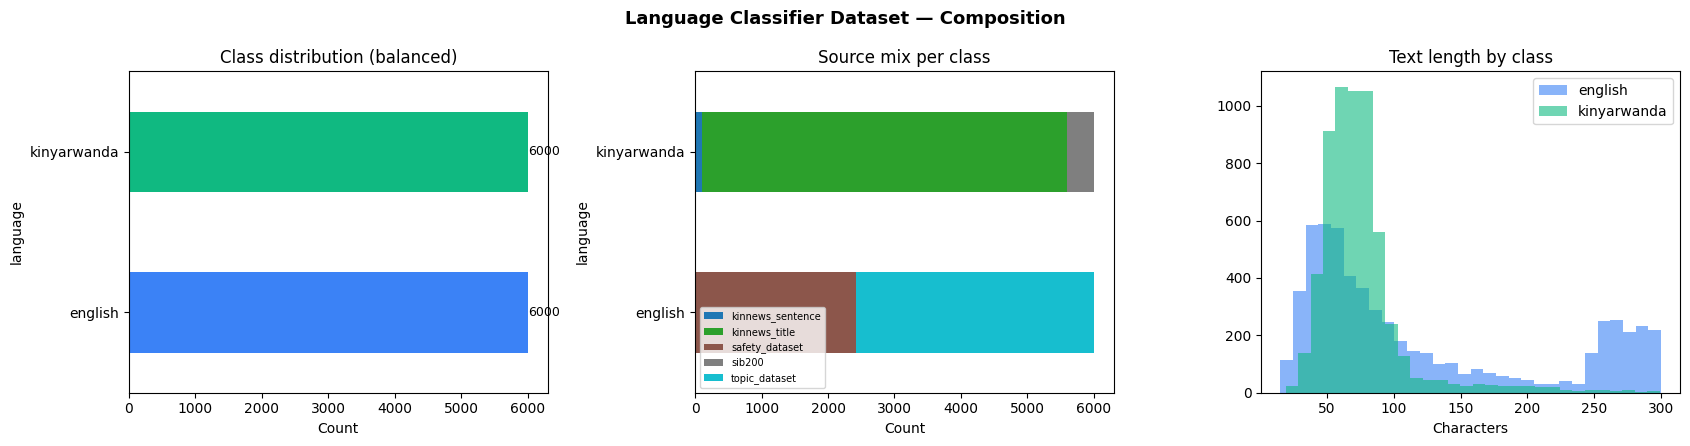

Text length by class:
              mean   min   25%   50%    75%    max
language                                          
english      121.8  15.0  50.0  82.0  192.0  300.0
kinyarwanda   75.0  19.0  57.0  69.0   83.0  299.0


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
fig.suptitle('Language Classifier Dataset — Composition', fontsize=13, fontweight='bold')

lang_counts = balanced['language'].value_counts()
lang_counts.plot(kind='barh', ax=axes[0], color=['#3B82F6', '#10B981'])
axes[0].set_title('Class distribution (balanced)'); axes[0].set_xlabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y()+p.get_height()/2),
                     ha='left', va='center', fontsize=9)

pivot = balanced.groupby(['language', 'source']).size().unstack(fill_value=0)
pivot.plot(kind='barh', stacked=True, ax=axes[1], colormap='tab10')
axes[1].set_title('Source mix per class'); axes[1].set_xlabel('Count'); axes[1].legend(fontsize=7)

for lang, color in [('english', '#3B82F6'), ('kinyarwanda', '#10B981')]:
    axes[2].hist(balanced[balanced['language'] == lang]['text_len'], bins=30,
                 alpha=0.6, label=lang, color=color)
axes[2].set_title('Text length by class'); axes[2].set_xlabel('Characters'); axes[2].legend()

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/lang_dataset_composition.png', dpi=150, bbox_inches='tight')
plt.show()

print('Text length by class:')
print(balanced.groupby('language')['text_len'].describe()[['mean','min','25%','50%','75%','max']].round(1).to_string())

---
## STEP 6 — Train/val/test split (70/15/15, stratified) & save

In [8]:
final = balanced[['text', 'language', 'label', 'source']].copy()
train_df, temp_df = train_test_split(final, test_size=0.30, stratify=final['label'], random_state=RANDOM_SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=RANDOM_SEED)

train_df.to_csv(f'{OUT_DIR}/lang_train.csv', index=False)
val_df.to_csv(f'{OUT_DIR}/lang_val.csv', index=False)
test_df.to_csv(f'{OUT_DIR}/lang_test.csv', index=False)
final.to_csv(f'{OUT_DIR}/lang_labels_full.csv', index=False)
with open(f'{OUT_DIR}/lang_label_map.json', 'w') as f:
    json.dump({'language_to_int': LANG_MAP, 'int_to_language': LANG_NAMES}, f, indent=2)

# Leakage guard
def _keys(df): return set(df['text'].str.strip().str.lower())
ktr, kva, kte = _keys(train_df), _keys(val_df), _keys(test_df)
assert not (ktr & kva) and not (ktr & kte) and not (kva & kte), 'LEAKAGE'

print('=' * 50); print('LANGUAGE DATASET — COMPLETE'); print('=' * 50)
print(f'  Train: {len(train_df):>5}  Val: {len(val_df):>5}  Test: {len(test_df):>5}  Total: {len(final):>5}')
print('  Leakage check: PASSED')
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'  {name:<6}', df['label'].value_counts().sort_index().to_dict())

LANGUAGE DATASET — COMPLETE
  Train:  8400  Val:  1800  Test:  1800  Total: 12000
  Leakage check: PASSED
  train  {0: 4200, 1: 4200}
  val    {0: 900, 1: 900}
  test   {0: 900, 1: 900}


---
## STEP 7 — Inspect samples per class

In [9]:
for lang in LANG_MAP:
    sub = final[final['language'] == lang]
    print(f'\n=== {lang.upper()} (label={LANG_MAP[lang]}) — {len(sub)} rows ===')
    for _, r in sub.sample(3, random_state=7).iterrows():
        print(f'  [{r["source"]}] {r["text"][:90]}')


=== ENGLISH (label=0) — 6000 rows ===
  [safety_dataset] How many cats would I need to bake to make a pie big enough to feed 10? They're medium-siz
  [topic_dataset] my husband has been treated with rituxin for leukemia CLL and now he has a knot in his gro
  [safety_dataset] Are there any natural methods to help me pass it?

=== KINYARWANDA (label=1) — 6000 rows ===
  [kinnews_title] ingingo zinezeza inkumi n’abagore bakiri bato
  [sib200] Afurika y’Epfo yatsinze All Blacks (New Zealand) mu mukino wa rugubi w’ubumwe bw’ibihugu T
  [kinnews_title] muri kaminuza y’u rwanda abanyeshuri babujijwe gusenga umutekano warakajijwe cyane
